In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# npz = np.load(Path("data/Gasecki/Gasecki_data_corr_total.npz"), allow_pickle=True)
# gasecki_e_xy = npz["E_xy"]

# npz = np.load(Path("data/Sobieski/Sobieski_data_corr_total.npz"), allow_pickle=True)
# sobieski_e_xy = npz["E_xy"]

# npz = np.load(Path("data/Matka_Boska/Matka_Boska_data_corr_total_Cu.npz"), allow_pickle=True)
# matka_boska_e_xy = npz["E_xy"]

npz = np.load(Path("data/Blank_PcbCu/GEM_Cr_PBS1_Blank_PcbCu_ArCO2_75_25_Gain_35_Thr_35_HV_3640_Xray_50kV_04mA_part_001_GainCorr.pcap.dat.npz"), allow_pickle=True)
cu_e_xy = npz["E_xy"]


In [4]:
from src.DataPreprocessor import DataPreprocessor
import numpy as np
from skimage.filters import gaussian

peaks_cu = [1000, 1614]
energies_cu = [5.088, 8.046]


energy_range, spectra = DataPreprocessor.processed_spectra(gaussian(cu_e_xy, sigma=1, channel_axis=-1), peaks_cu, energies_cu)
spectra = spectra[:,:, 200:4000]

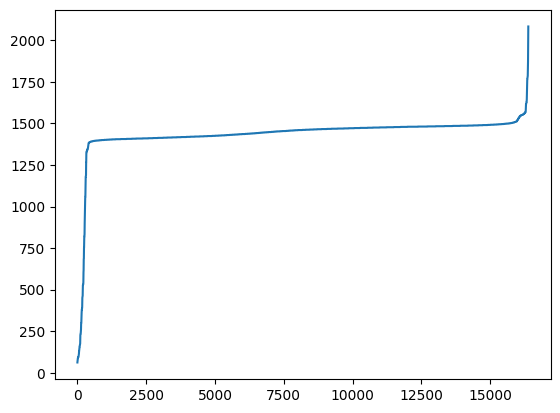

<Figure size 1000x1000 with 0 Axes>

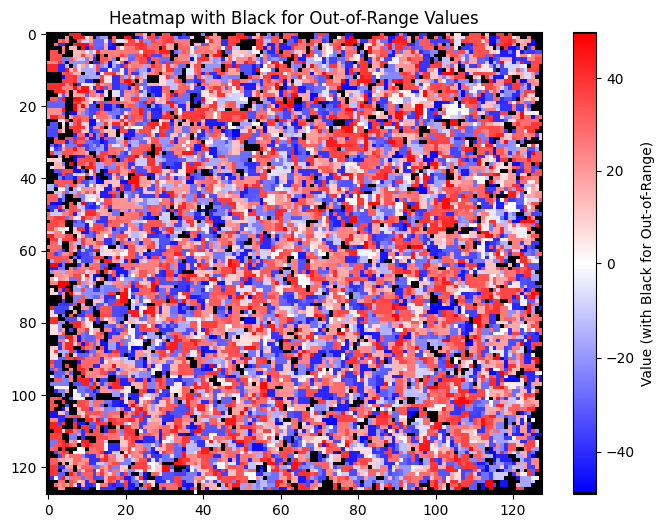

In [5]:
import matplotlib.colors as mcolors
import numpy as np

max_positions = np.argmax(spectra, axis=2)
im = max_positions.copy()

plt.plot(sorted(im.flatten()))
plt.figure(figsize=(10, 10))


vmin, vmax = np.percentile(im, [5, 95])
ill_values_predicate = np.logical_or(im < vmin, im > vmax)
im[ill_values_predicate] = 10e10
vmid = int((vmax + vmin) / 2)
im -= vmid
vmin, vmax = vmin - vmid, vmax - vmid


cmap = plt.cm.bwr
colors = cmap(np.linspace(0, 1, 256))

centered_norm = mcolors.TwoSlopeNorm(vmin=vmin , vcenter=0, vmax=vmax)

colors = np.vstack(([0, 0, 0, 1], colors, [0, 0, 0, 1]))
custom_cmap = mcolors.ListedColormap(colors)

# Define the boundaries
boundaries = np.linspace(vmin, vmax, 256)
boundaries = np.concatenate(([im.min()], boundaries, [im.max()]))

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(im, cmap=custom_cmap, norm=centered_norm, aspect="auto")
plt.colorbar(label="Value (with Black for Out-of-Range)")
plt.title("Heatmap with Black for Out-of-Range Values")
plt.show()
